In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi
from plot_utils import *


import warnings
warnings.filterwarnings("ignore")

Bag-of-trick-ResNet18-AA


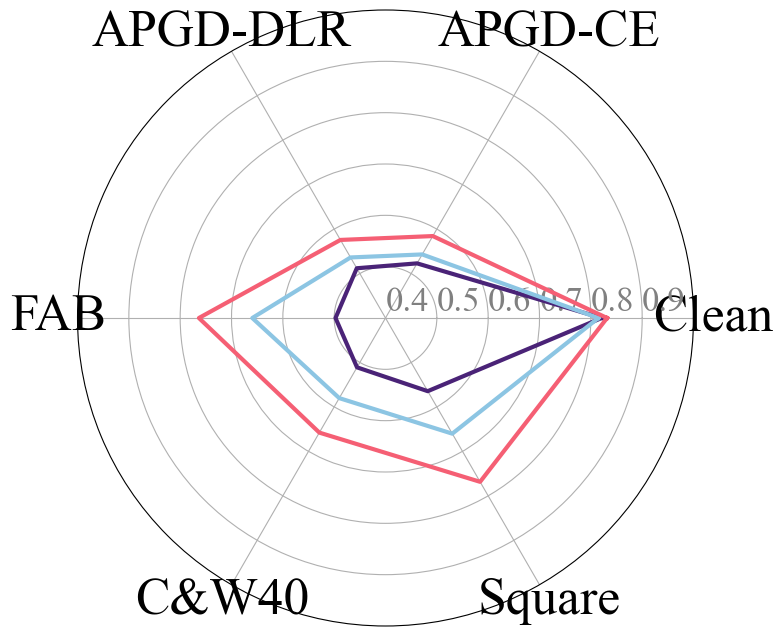

Pang2022Robustness_WRN28_10


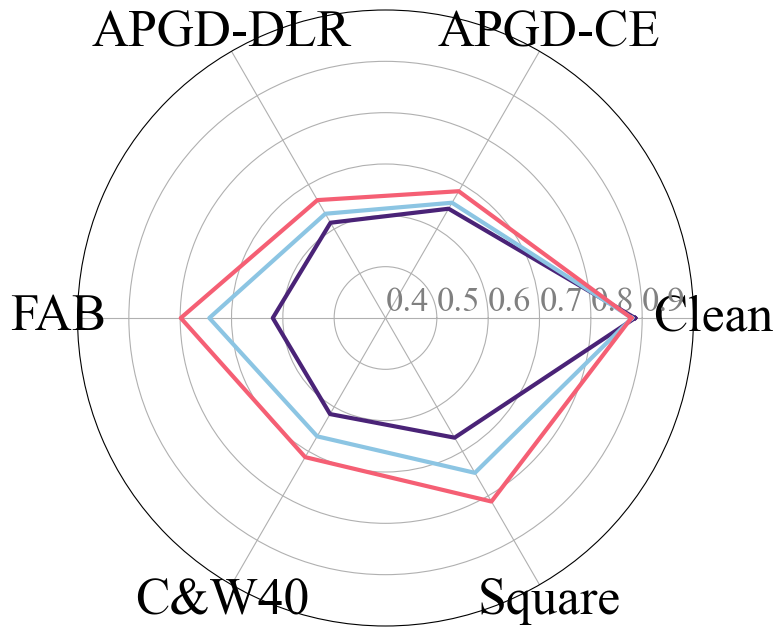

Rade2021Helper_extra


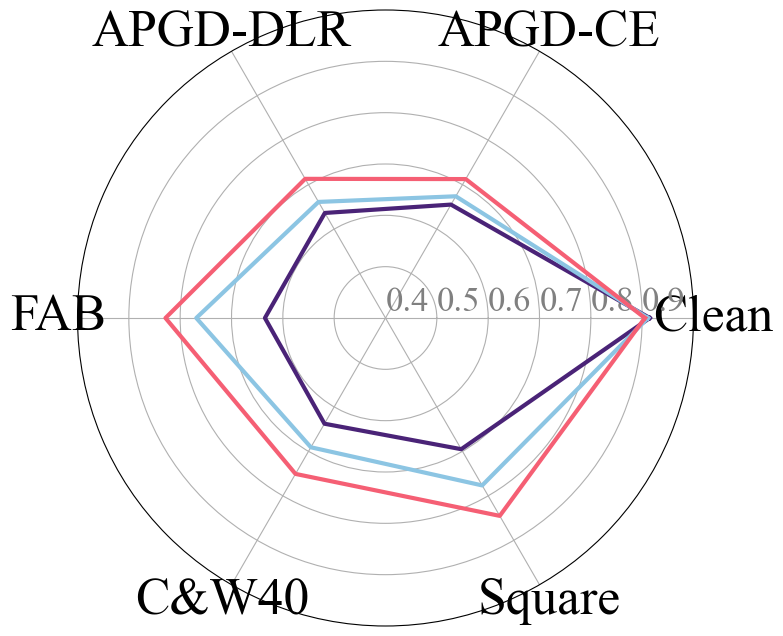

Xu2023Exploring_WRN-28-10


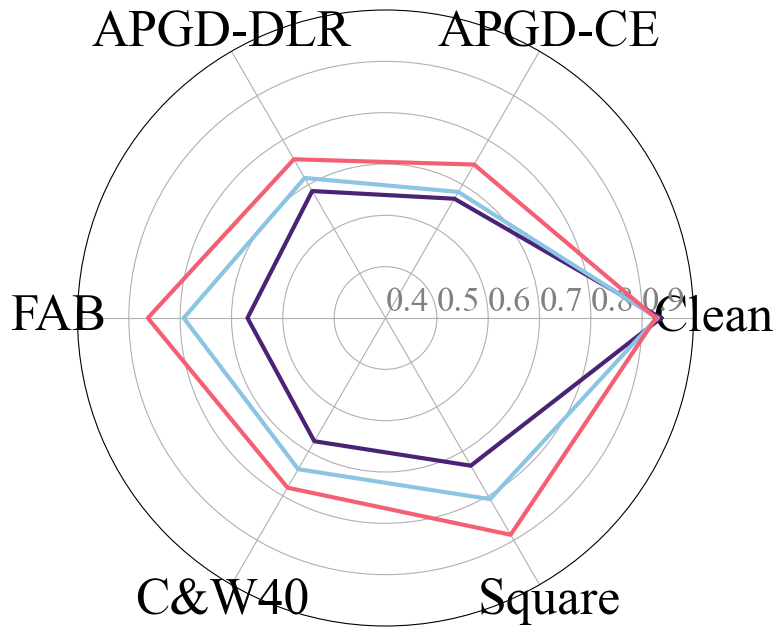

Cui2023Decoupled_WRN-28-10


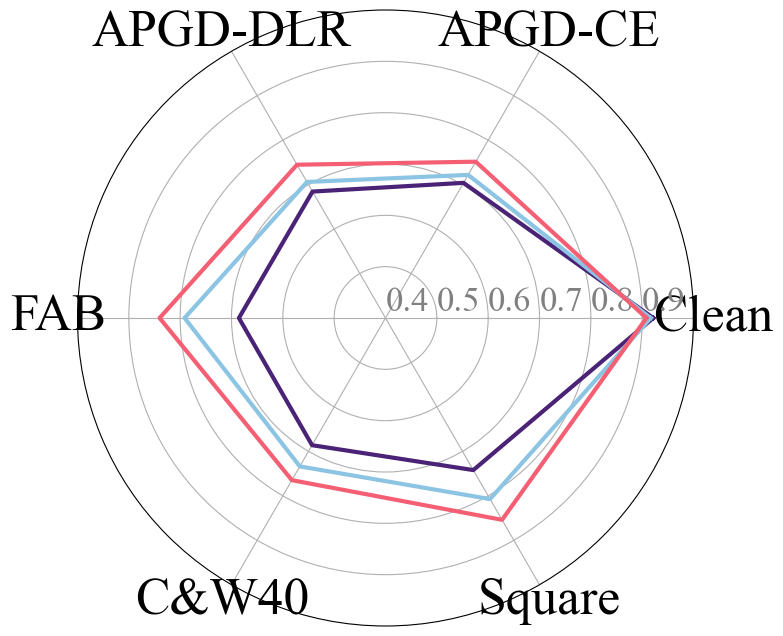

Wang2023Better_WRN-28-10


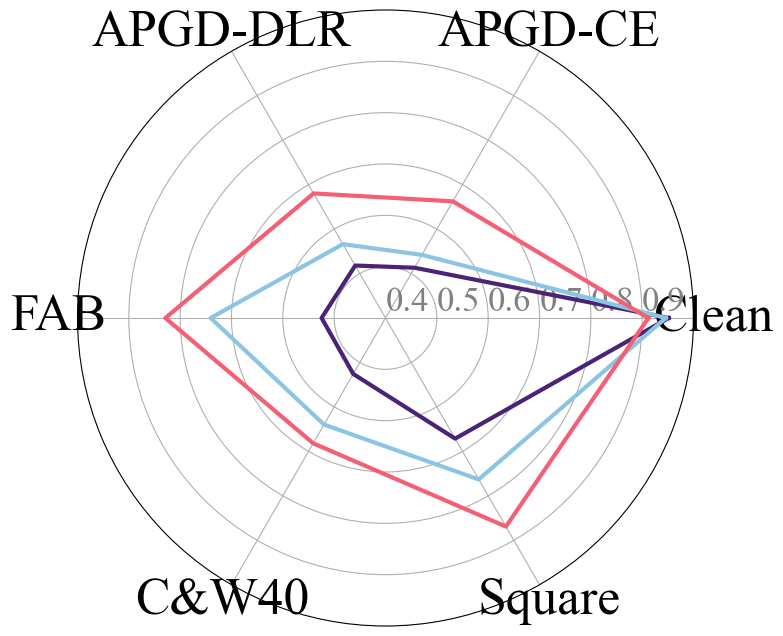

Debenedetti2022Light_XCiT-M12


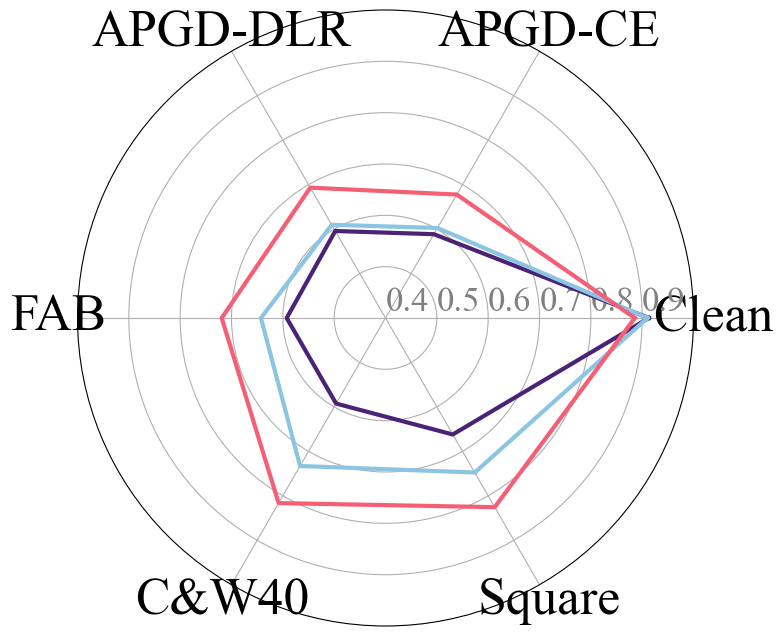

Peng2023RobustWRN-70-16


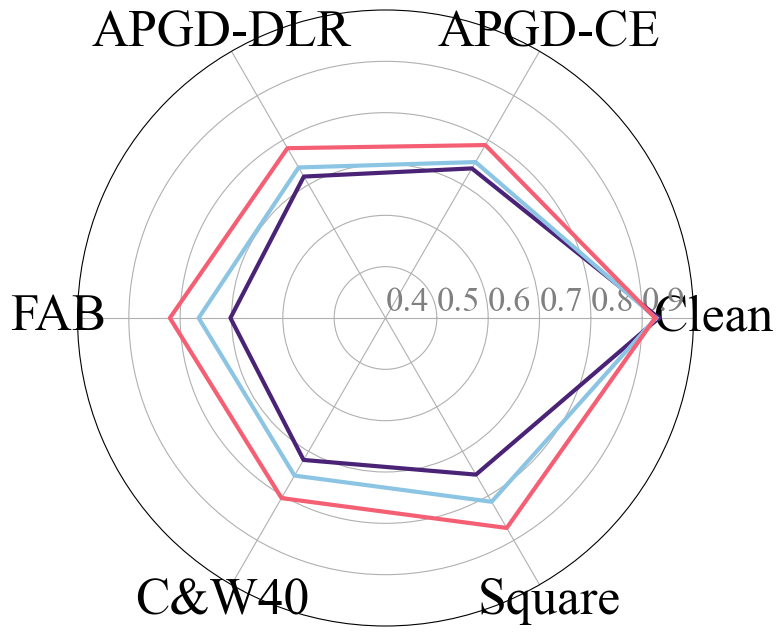

CF100CuiWRN-28-10


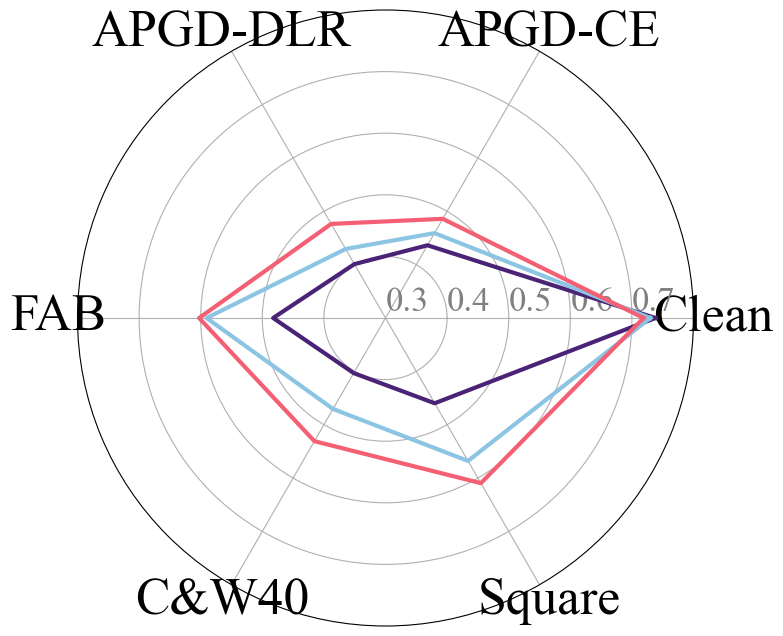

Flower102-XCiT-S12


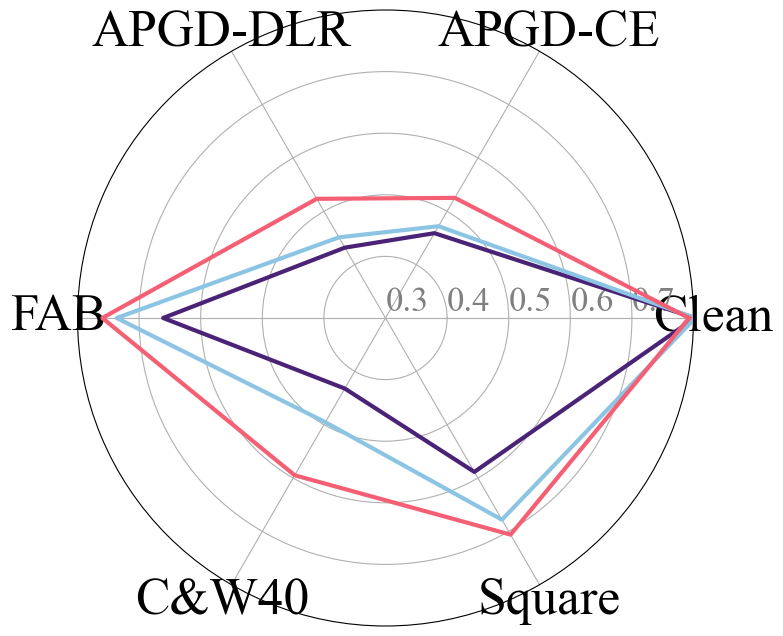

finish


In [ ]:
fontsize=37
trickszie=25
legedsize=15

modellist=['Bag-of-trick-ResNet18-AA','Pang2022Robustness_WRN28_10','Rade2021Helper_extra',
           'Xu2023Exploring_WRN-28-10','Cui2023Decoupled_WRN-28-10','Wang2023Better_WRN-28-10',
          'Debenedetti2022Light_XCiT-M12','Peng2023RobustWRN-70-16','CF100CuiWRN-28-10','Flower102-XCiT-S12']


methods = ['Clean', 'APGD-CE', 'APGD-DLR', 'FAB','C&W40', 'Square']

cols = ['No Smoothing', 'Randomized', 'SelfPure']

# Initialize an empty DataFrame for the final table


for model in modellist:
    root_dir = r'./csvout/' + model
    # Initialize an empty DataFrame for the final table
    final_table = pd.DataFrame(index=methods, columns=['No Smoothing', 'Randomized', 'SelfPure'])
    print(model)
    for i, file in enumerate(os.listdir(root_dir)):
        if "BPDA" in file or "bypass" in file:
            print(file)
            continue
        if 'csv' not in file:
            continue
        data = pd.read_csv(os.path.join(root_dir, file), encoding='utf-8')
        raw, rand, pro = GR_confusion_compare_matrix(data)
        if i == 0:
            first_index=[raw[0] + raw[1], rand[0] + rand[1], pro[0] + pro[1]]
            final_table.loc[methods[i]] = first_index

        first_index = [raw[0] , rand[0] , pro[0]]
        final_table.loc[methods[i+1]] = first_index

    final_table=final_table.T*1

    # Number of variables
    categories = list(final_table)
    N = len(categories)

    # What will be the angle of each axis in the plot? (we divide the plot / number of variable)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    plt.figure(figsize=(8,8))
    plt.cla()
    plt.rcParams['axes.prop_cycle'] = custom_cycler
    plt.rc('font',family='Times New Roman')
    # Initialise the spider plot
    ax = plt.subplot(111, polar=True)
    # Draw one axe per variable + add labels labels yet
    plt.xticks(angles[:-1], categories,fontsize=fontsize)
#     plt.yticks(fontsize=12)

    if model in ['CF100CuiWRN-28-10','Flower102-XCiT-S12']:
        plt.yticks([0.3,0.4,0.5,0.6,0.7], ["0.3","0.4","0.5","0.6","0.7"], color="grey", fontsize=trickszie)
        plt.ylim(0.3, 0.8)
    else:
        plt.yticks([0.4,0.5,0.6,0.7,0.8,0.9], ["0.4","0.5","0.6","0.7","0.8","0.9"], color="grey", fontsize=trickszie)
        plt.ylim(0.4, 1.0)
    # Draw ylabels
    ax.set_rlabel_position(0)
    # plt.yticks([0.0, 1.0], ["0.0", "1.0"], color="grey", size=7)
    plt.ylim(0.4, 1.0)

    # Plot data
    for i, method in enumerate(cols):
        values = final_table.iloc[i].tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=3, linestyle='solid', label=method)
        ax.fill(angles, values,  alpha=0)  # Set alpha=0 for no fill

    # Add a legend
    # plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
#     plt.legend(loc='upper right', bbox_to_anchor=(1.4, 0.05),prop={'family' : 'Times New Roman', 'size'   : legedsize})
#     plt.savefig('./paperfile/{}_with_legend.png'.format(model))
    plt.savefig('./figure/{}.png'.format(model),bbox_inches = 'tight')
    # Show the plot
    plt.show()

    # secondindex=[raw[0], rand[0], pro[0]]
print('finish')
